<a href="https://colab.research.google.com/github/karinenoronha/Agricultural-Material/blob/main/Marketing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Marketing Performance Analytics

In [2]:
#Importing library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("marketing_campaign.csv", sep="\t" )
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
# cleanning data

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)


In [10]:
df.dropna()
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [11]:
#creating additional variables


#age
df['Age'] = 2026 - df['Year_Birth']

#Total Spent
df['Total_Spent'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spent
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,69,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,72,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,61,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,42,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,45,422


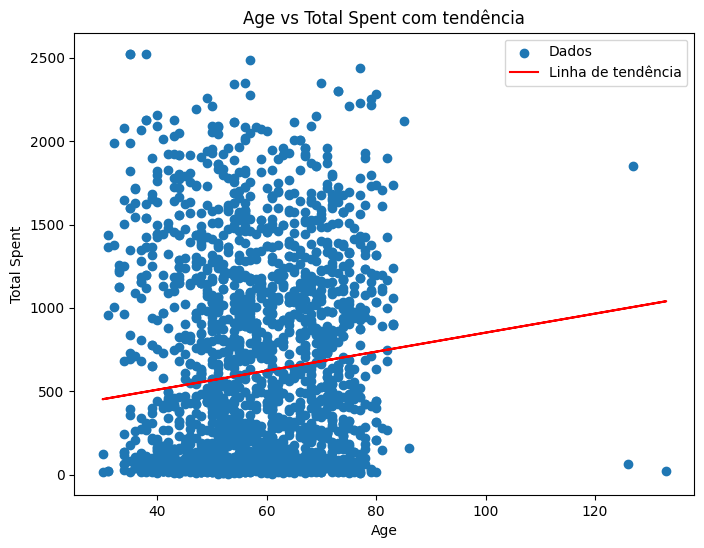

In [37]:
x = df["Age"]
y = df["Total_Spent"]

# regressão linear (linha de tendência)
coef = np.polyfit(x, y, 1)   # grau 1 = linha reta
trend = np.poly1d(coef)

plt.figure(figsize=(8,6))

# pontos
plt.scatter(x, y, label="Dados")

# linha de tendência
plt.plot(x, trend(x), color="red", label="Linha de tendência")

plt.xlabel("Age")
plt.ylabel("Total Spent")
plt.title("Age vs Total Spent com tendência")
plt.legend()

plt.show()

There is no big diffrent when the age grows

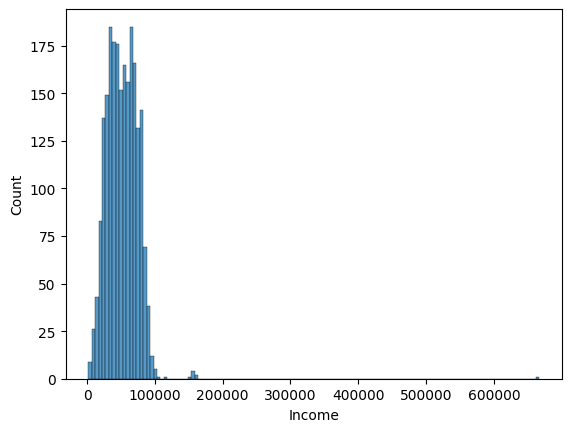

In [13]:
sns.histplot(df['Income'])
plt.show()

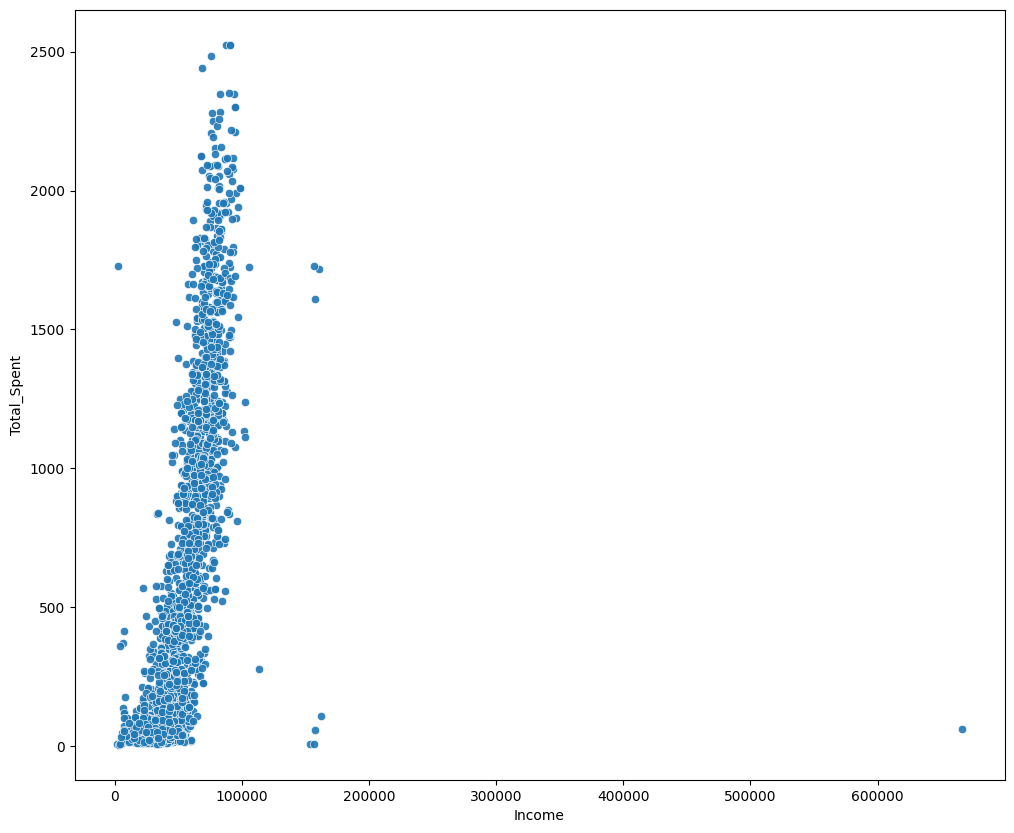

In [21]:
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spent",
    alpha=0.9
)

plt.show()

“Customers with higher income tend to have higher total spending, indicating a strong correlation between purchasing power and consumption.”

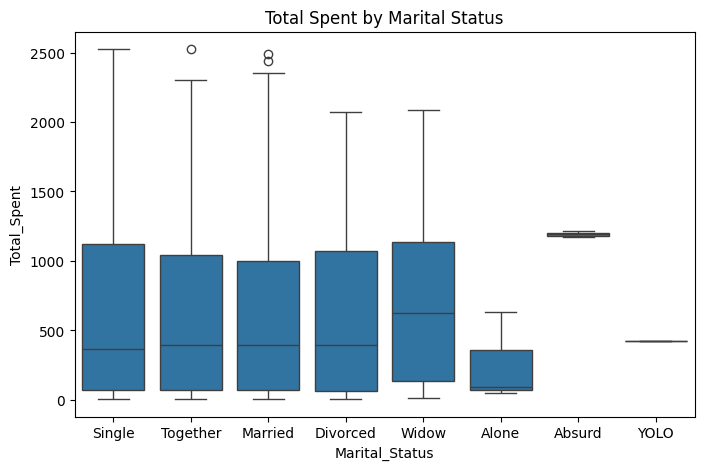

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Marital_Status", y="Total_Spent")

plt.title("Total Spent by Marital Status")
plt.show()

There does not appear to be a substantial difference in spending among the different marital status groups

**Open SQLlite3 to manipulate data in SQL**

In [29]:
import sqlite3

conn = sqlite3.connect('marketing_campaign.db')
df.to_sql('marketing_campaign', conn, if_exists='replace', index=False)

df.to_sql("customers", conn, if_exists="replace", index=False)

2216

In [30]:
query = """

SELECT education, AVG(Income) as avg_income, SUM (MntWines + MntFruits + MntMeatProducts) as revenue
FROM customers
GROUP BY education
ORDER BY revenue DESC;

"""

pd.read_sql_query(query, conn)

,Education,avg_income,revenue
0,Graduation,52720.373656,553871
1,PhD,56145.313929,287208
2,Master,52917.534247,188806
3,2n Cycle,47633.190000,73057
4,Basic,20306.259259,1609


it can be observed that individuals with only a bachelor's degree tend to spend more than those with a master's degree or a PhD, as well as those whose education level is at most secondary education.

In [40]:
df.to_csv("marketing_processed.csv", index=False)

In [41]:
from google.colab import files
files.download("marketing_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>